In [10]:
import random
import string
from datetime import datetime, timedelta
import psycopg2
from psycopg2 import sql
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.ticker as mtick  # Importa el módulo para formatear el eje
import re # Expresiones regulares
from IPython.display import display


In [12]:
# ------------ FUNCIONES ----------------

# 1. Conexión con BD
# 1.1 Con PSYCOPG2
def conexionBDPostgresSQL():
    # Se omiten los datos de conexión.
    conexion = psycopg2.connect(
        dbname="",
        user="",
        password="",
        host="",
        port=""
    )
    return conexion



# 0.
def obtenerDatosBBDD(comandoSQL):
    # Crear conexión y obtener cursor
    conexionBD = conexionBDPostgresSQL() #conexionBDPostgresSQL()
    cursor = conexionBD.cursor()

    # Ejecutar comando y obtener datos
    cursor.execute(comandoSQL)
    registros = cursor.fetchall()

    # Obtener columnas desde el cursor
    columnas = [desc[0] for desc in cursor.description]
    cursor.close()
    conexionBD.close()
    return registros, columnas


# 1. Obtener datos emisiones (procesados)
def obtenerDataframeemisiones():
  comandoSQL_emisiones = "SELECT * FROM tfm.emisiones_procesada ORDER BY \"fecha\" ASC"
  datosemisiones, columnasemisiones =  obtenerDatosBBDD(comandoSQL_emisiones)
  df_emisiones = pd.DataFrame(datosemisiones, columns=columnasemisiones)
  return df_emisiones

def emisiones_InsertBD_SQLALCHEMY(dataframeemisiones):
  # Datos de conexión a POSTGRESQL
  usuario = ''
  password = ''
  servidor = ''  
  puerto = ''
  basedatos = ''

  # Crear la URL de conexión
  urlConexion = f'postgresql+psycopg2://{usuario}:{password}@{servidor}:{puerto}/{basedatos}'
  # Motor conexión Postgresql
  engine = create_engine(urlConexion)

  # Tabla y Esquema de BD
  esquemaBD = 'tfm'
  tabla = 'emisiones_final'

  # Insertar en BBDD desde un Dataframe
  dataframeemisiones.to_sql(tabla, engine, schema=esquemaBD, if_exists='append', index=False)



def crearColumnasAnyoMesDia(dataset):
  # Crear nuevas columnas
  dataset['Año'] = dataset['fecha'].dt.year
  dataset['Mes'] = dataset['fecha'].dt.month
  dataset['Dia'] = dataset['fecha'].dt.day
  dataset['DiaSemana'] = dataset['fecha'].dt.weekday + 1  # +1 para que 1=Lunes, ..., 7=Domingo
  return dataset



def generarGraficasDistribucion_2filas_gen(dataset,fecha,mes,dia_semana,columna):

    diccionarioMeses = {
        1: 'Enero',
        2: 'Febrero',
        3: 'Marzo',
        4: 'Abril',
        5: 'Mayo',
        6: 'Junio',
        7: 'Julio',
        8: 'Agosto',
        9: 'Septiembre',
        10: 'Octubre',
        11: 'Noviembre',
        12: 'Diciembre'
    }
    diccionarioDiaSemana = {
        1: 'Lunes',
        2: 'Martes',
        3: 'Miércoles',
        4: 'Jueves',
        5: 'Viernes',
        6: 'Sábado',
        7: 'Domingo'
    }
    # Ajustar tamaño de la figura para 1 fila de 3 gráficos y 1 fila de 1 gráfico que ocupe todo el ancho
    fig = plt.figure(figsize=(15, 10), dpi=300)
    # Crear subplots manualmente
    ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=1)
    ax2 = plt.subplot2grid((3, 3), (0, 1), colspan=1)
    ax3 = plt.subplot2grid((3, 3), (0, 2), colspan=1)
    ax4 = plt.subplot2grid((3, 3), (1, 0), colspan=3, rowspan=1)  # Este eje ocupa toda la segunda fila
    
    # emisiones por día de la semana
    
    # Agrupar los datos por la columna especificada y calcular la media de los valores en esos grupos
    df_agrupado_dia = dataset.groupby(dia_semana)[columna].mean().reset_index()

    # Calcular la media global de la columna agrupada (después de agrupar)
    media_global = df_agrupado_dia[columna].mean()
    
    etiquetas_traducidas_dia = [diccionarioDiaSemana.get(label, label) for label in df_agrupado_dia[dia_semana]]

    # Crear el gráfico de barras
    bar_positions = range(len(df_agrupado_dia[columna]))
    ax1.bar(bar_positions, df_agrupado_dia[columna], color='lightcoral')

    # Añadir la línea de la media global de los valores agrupados
    ax1.axhline(y=media_global, color='red', linestyle='--', label=f'Valor medio: ({media_global:.2f})')
    # Reducir el tamaño de la leyenda
    ax1.legend(loc='upper right', framealpha=0.5, fontsize='small')


    # Añadir etiquetas y título
    #ax1.xlabel(columna_para_agrupar.capitalize())
    #ax1.ylabel('Valor emisiones media')
    ax1.set_title(f'Emisiones por día de la semana de: {columna.upper()}')

    # Configurar xticks manualmente para mostrar todas las etiquetas correctamente alineadas
    ax1.set_xticks(ticks=bar_positions, labels=etiquetas_traducidas_dia, rotation=45, ha='right')

    # emisiones por mes
    
    # Agrupar los datos por la columna especificada y calcular la media de los valores en esos grupos
    df_agrupado_mes = dataset.groupby(mes)[columna].mean().reset_index()

    # Calcular la media global de la columna agrupada (después de agrupar)
    media_global = df_agrupado_mes[columna].mean()

    # Crear el gráfico de barras
    bar_positions = range(len(df_agrupado_mes[columna]))
    ax2.bar(bar_positions, df_agrupado_mes[columna], color='khaki')

    # Añadir la línea de la media global de los valores agrupados
    ax2.axhline(y=media_global, color='red', linestyle='--', label=f'Valor medio: ({media_global:.2f})')
    # Reducir el tamaño de la leyenda
    ax2.legend(loc='upper right', framealpha=0.5, fontsize='small')

    etiquetas_traducidas_mes = [diccionarioMeses.get(label, label) for label in df_agrupado_mes[mes]]

    # Añadir etiquetas y título
    #ax2.xlabel(columna_para_agrupar.capitalize())
    #ax2.ylabel('Valor emisiones media')
    ax2.set_title(f'Emisiones por mes del año de: {columna.upper()}')

    # Configurar xticks manualmente para mostrar todas las etiquetas correctamente alineadas
    #plt.xticks(ticks=bar_positions, labels=etiquetas_traducidas, rotation=45, ha='right')


    # Histograma
    sns.histplot(dataset[columna], kde=True, ax=ax3,  color='paleturquoise')
    ax3.set_title(f'Histograma de: {columna.upper()}')
    #ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    #ax2.tick_params(axis='x', labelsize=8.5) # Sólo si se solapan los textos
    #ax2.set_ylabel('Etiqueta EJE Y')
    
    #Serie temportal

    if not pd.api.types.is_datetime64_any_dtype(dataset['fecha']):
        dataset['fecha'] = pd.to_datetime(dataset['fecha'])

    ax4.plot(dataset['fecha'], dataset[columna], linestyle='-', color='plum')
    ax4.set_title(f'Serie Temporal de: {columna.upper()}')
    ax4.set_xlabel('Fecha')
    ax4.set_ylabel('Valor')

    # Establecer el formato del eje x para mostrar cada año
    ax4.xaxis.set_major_locator(mdates.YearLocator())
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Añadir líneas verticales punteadas en cada año
    years = mdates.YearLocator()  # Localizador de años
    for year_loc in years.tick_values(dataset['fecha'].min(), dataset['fecha'].max()):
        ax4.axvline(x=year_loc, color='gray', linestyle='dashed', linewidth=1)

    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)  # Rotar las etiquetas si es necesario para mejor visualización
    
    # Use the pyplot interface to change just one subplot...
    
    plt.sca(ax2)
    plt.xticks(ticks=bar_positions, labels=etiquetas_traducidas_mes, rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'emisiones_{columna}.jpg')
    plt.show()




## emisiones
Ahora que ya hemos creado todas las funciones que vamos a usar en este análisis, vamos a importar los datos a un dataframe y empezar a trabajar con ellos.

In [14]:
# 1. emisiones
dataframeemisiones = obtenerDataframeemisiones()
# Asegurar que todos los dataframe tiene un campo llamado "fecha"
dataframeemisiones = dataframeemisiones.rename(columns={'fechaemisiones': 'fecha'})
dataframeemisiones.dtypes

fecha              datetime64[ns]
carbon                     object
ciclocombinado             object
cogeneracion                int64
fuelgas                    object
motordiesel                object
turbinagas                 object
turbinavapor               object
residuosnorenov            object
emisionestotal             object
emisionespormwh            object
dtype: object

Como los tipos de datos importados desde la tabla de PostgreSQLno estan bien, es necesario transformar la columna valor emisiones a valor numérico

In [16]:
columnas_numericas = ["carbon",
                      "ciclocombinado",
                      "cogeneracion",
                      "fuelgas",
                      "motordiesel",
                      "turbinagas",
                      "turbinavapor",
                      "residuosnorenov",
                      "emisionestotal",
                      "emisionespormwh"]
dataframeemisiones[columnas_numericas] = dataframeemisiones[columnas_numericas].apply(pd.to_numeric, errors='coerce')
dataframeemisiones.dtypes

fecha              datetime64[ns]
carbon                    float64
ciclocombinado            float64
cogeneracion                int64
fuelgas                   float64
motordiesel               float64
turbinagas                float64
turbinavapor              float64
residuosnorenov           float64
emisionestotal            float64
emisionespormwh           float64
dtype: object

Ahora que ya hemos ajustado los tipos de datos vamos, vamos a usar la función describe para ver un resumen de los datos del dataframe

In [8]:
dataframeemisiones.describe(include='all')

,fecha,carbon,ciclocombinado,cogeneracion,fuelgas,motordiesel,turbinagas,turbinavapor,residuosnorenov,emisionestotal,emisionespormwh
count,5114,5114.000000,5114.000000,5114.0,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2017-12-31 12:00:00,70710.730295,43895.818539,0.0,0.164822,6265.752596,1990.571370,4911.225449,1431.156121,157686.638534,0.216590
min,2011-01-01 00:00:00,0.000000,10760.109000,0.0,0.000000,3176.245000,104.502000,530.626000,274.960000,42932.844000,0.056991
25%,2014-07-02 06:00:00,10437.435500,26817.702500,0.0,0.000000,4932.930750,1319.299000,3370.490500,1017.738000,96356.198250,0.139280
50%,2017-12-31 12:00:00,47304.981000,37215.734000,0.0,0.000000,6520.552500,1882.108000,5172.949000,1418.865000,140973.366500,0.200411
75%,2021-07-01 18:00:00,130733.492250,56240.286000,0.0,0.000000,7476.514250,2560.441250,6349.912000,1782.961250,217949.162750,0.299831
max,2024-12-31 00:00:00,226270.304000,150182.113000,0.0,48.469000,9611.469000,5314.851000,8473.671000,2507.683000,366213.972000,0.425601
std,NaN,64960.416655,22833.240946,0.0,1.791094,1471.014003,917.293957,1702.652110,480.610294,72236.815327,0.091958


En este caso vemos que hay columnas que no nos aportam mucha información, como la coemisiones o el fuel y gas, que tiene valore de 0 siempre o casi siempre, por eso vamos a descartar esas dos columnas en el análisis visual de la tabla.

Veamos  ahora si el dataframe tiene las dimensiones esperadas.

In [18]:
print("Dimensiones: ", dataframeemisiones.shape)

Dimensiones:  (5114, 11)


Veamos ahora que no hay valores duplicados en nuestro dataset.

In [12]:
# Comprobar si hay duplicados
duplicados = dataframeemisiones.duplicated()

# Mostrar los registros duplicados (esto incluye la primera aparición)
df_duplicados = dataframeemisiones[duplicados]

# Mostrar el resultado
print("Registros duplicados:")
print(df_duplicados)

Registros duplicados:
Empty DataFrame
Columns: [fecha, carbon, ciclocombinado, cogeneracion, fuelgas, motordiesel, turbinagas, turbinavapor, residuosnorenov, emisionestotal, emisionespormwh]
Index: []


Por último, vamos a crear las columnas necesaria para los visuales, estas son las columnas de año, mes, dia y dia de la semana.

In [20]:
dataframeemisiones = crearColumnasAnyoMesDia(dataframeemisiones)
dataframeemisiones.head()

,fecha,carbon,ciclocombinado,cogeneracion,fuelgas,motordiesel,turbinagas,turbinavapor,residuosnorenov,emisionestotal,emisionespormwh,Año,Mes,Dia,DiaSemana
0,2011-01-01,60383.610,56093.042,0,0.0,7868.698,608.304,5638.806,834.389,154243.218,0.247060,2011,1,1,6
1,2011-01-02,60109.235,42428.998,0,0.0,8004.911,793.377,6507.919,850.047,144533.993,0.212542,2011,1,2,7
2,2011-01-03,94407.316,84837.898,0,0.0,8365.888,2132.724,7610.614,864.455,232311.894,0.276871,2011,1,3,1
3,2011-01-04,109372.271,78843.807,0,0.0,8357.493,2356.721,7436.203,818.393,242568.461,0.280973,2011,1,4,2
4,2011-01-05,68354.036,44705.522,0,0.0,8398.663,1674.490,7328.523,835.749,165656.989,0.198794,2011,1,5,3


Y podemos sacar ya los gráficos, vamos a obtener una gráfica por cada columna de emisiones de energía.

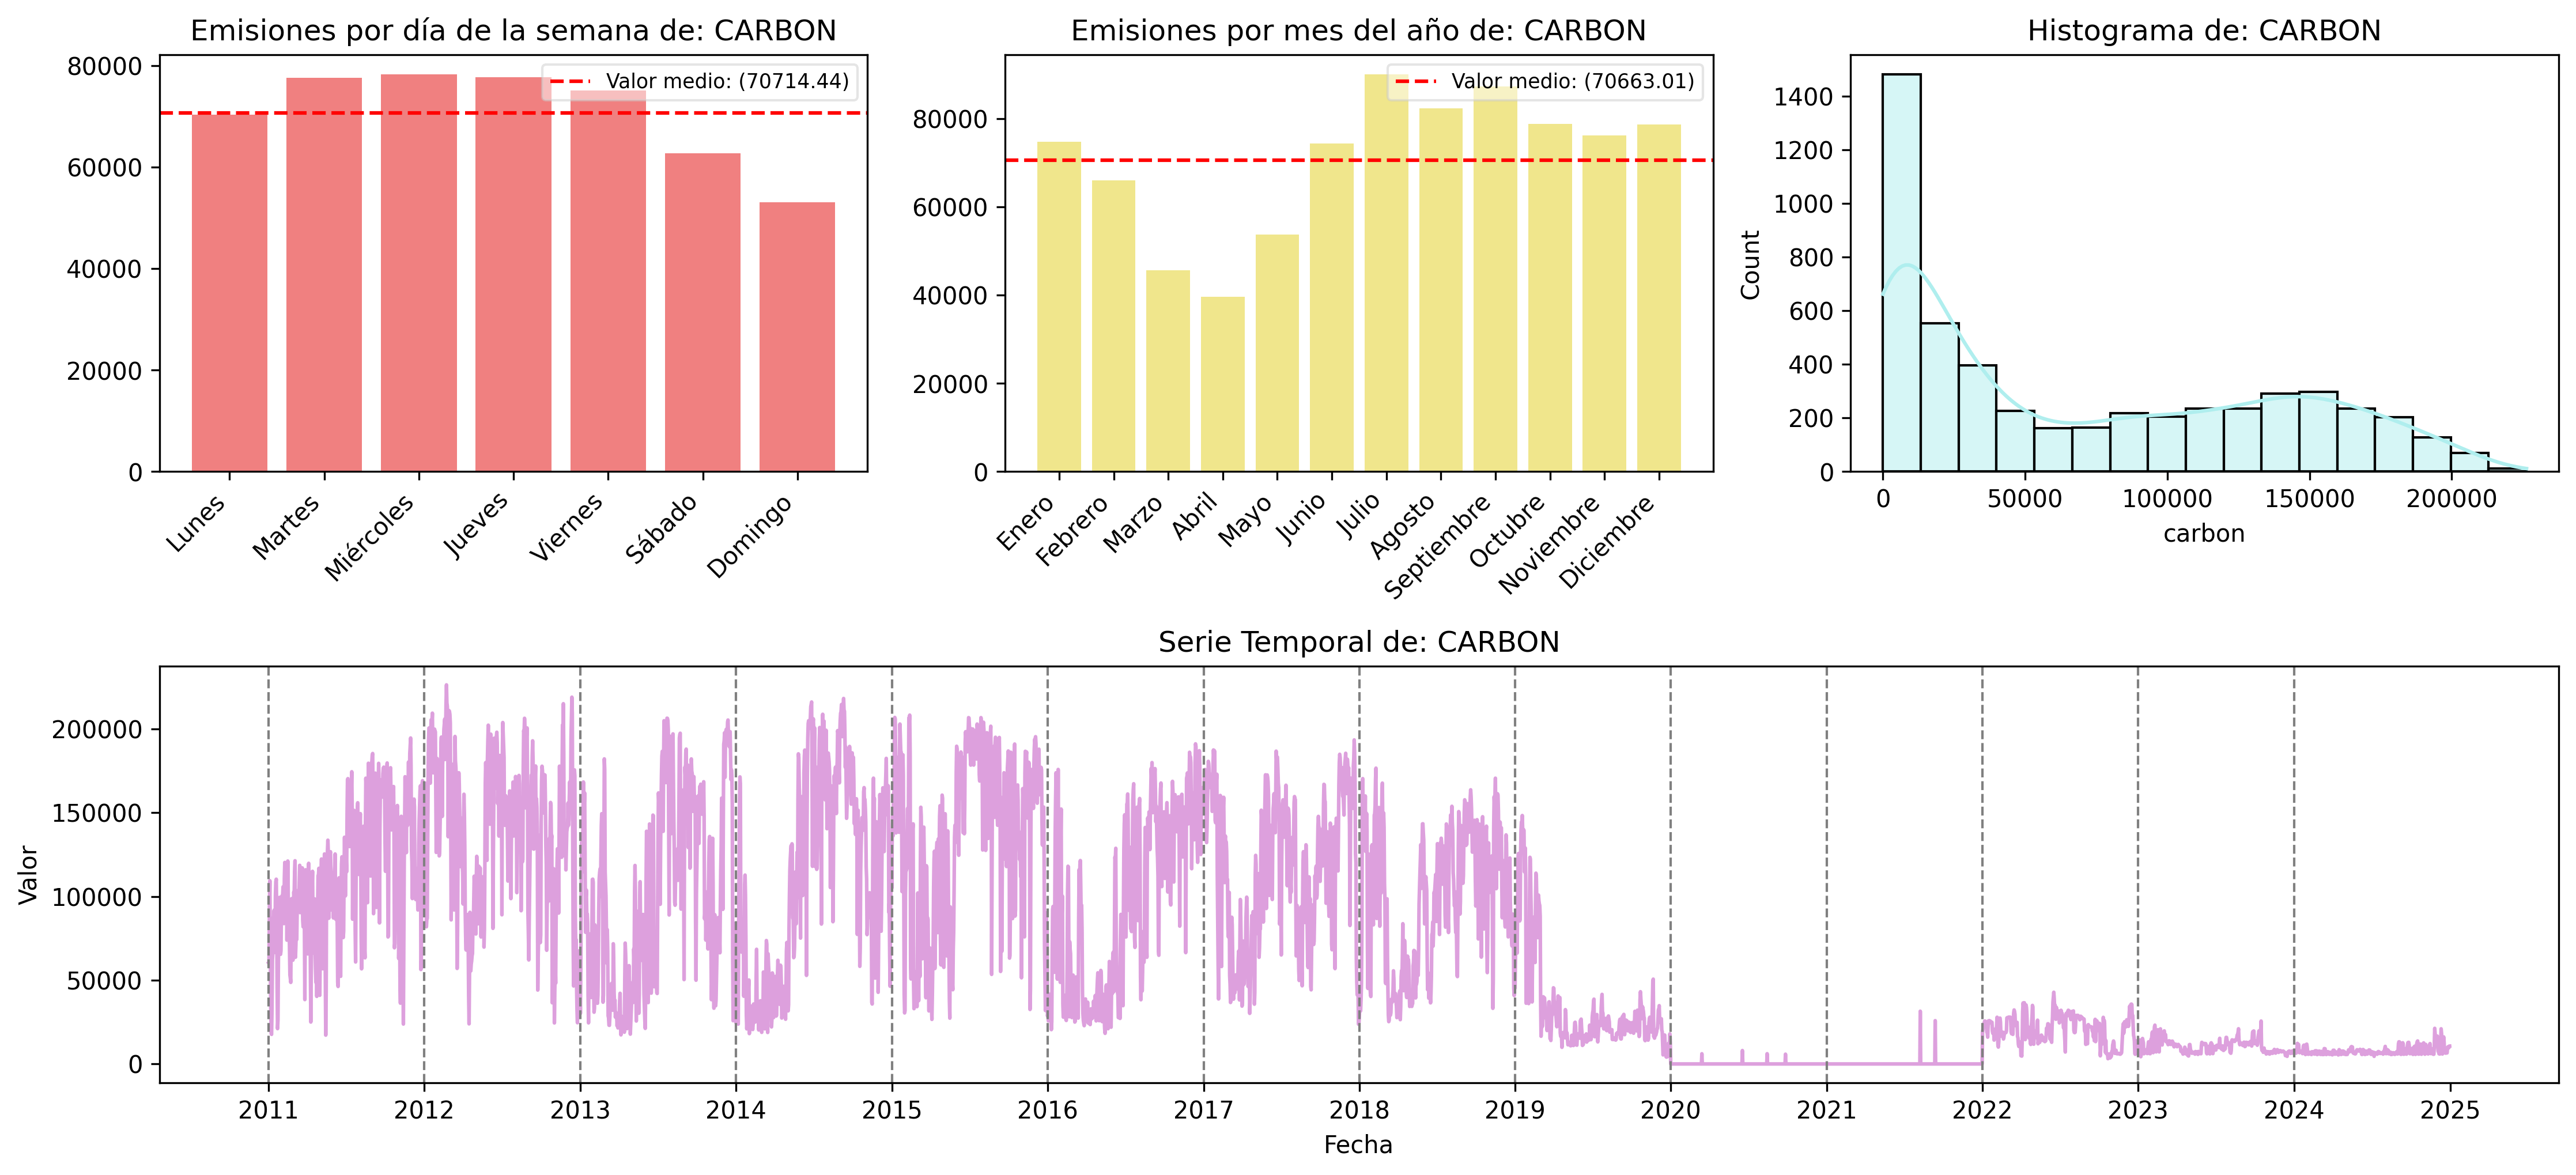

In [16]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','carbon')

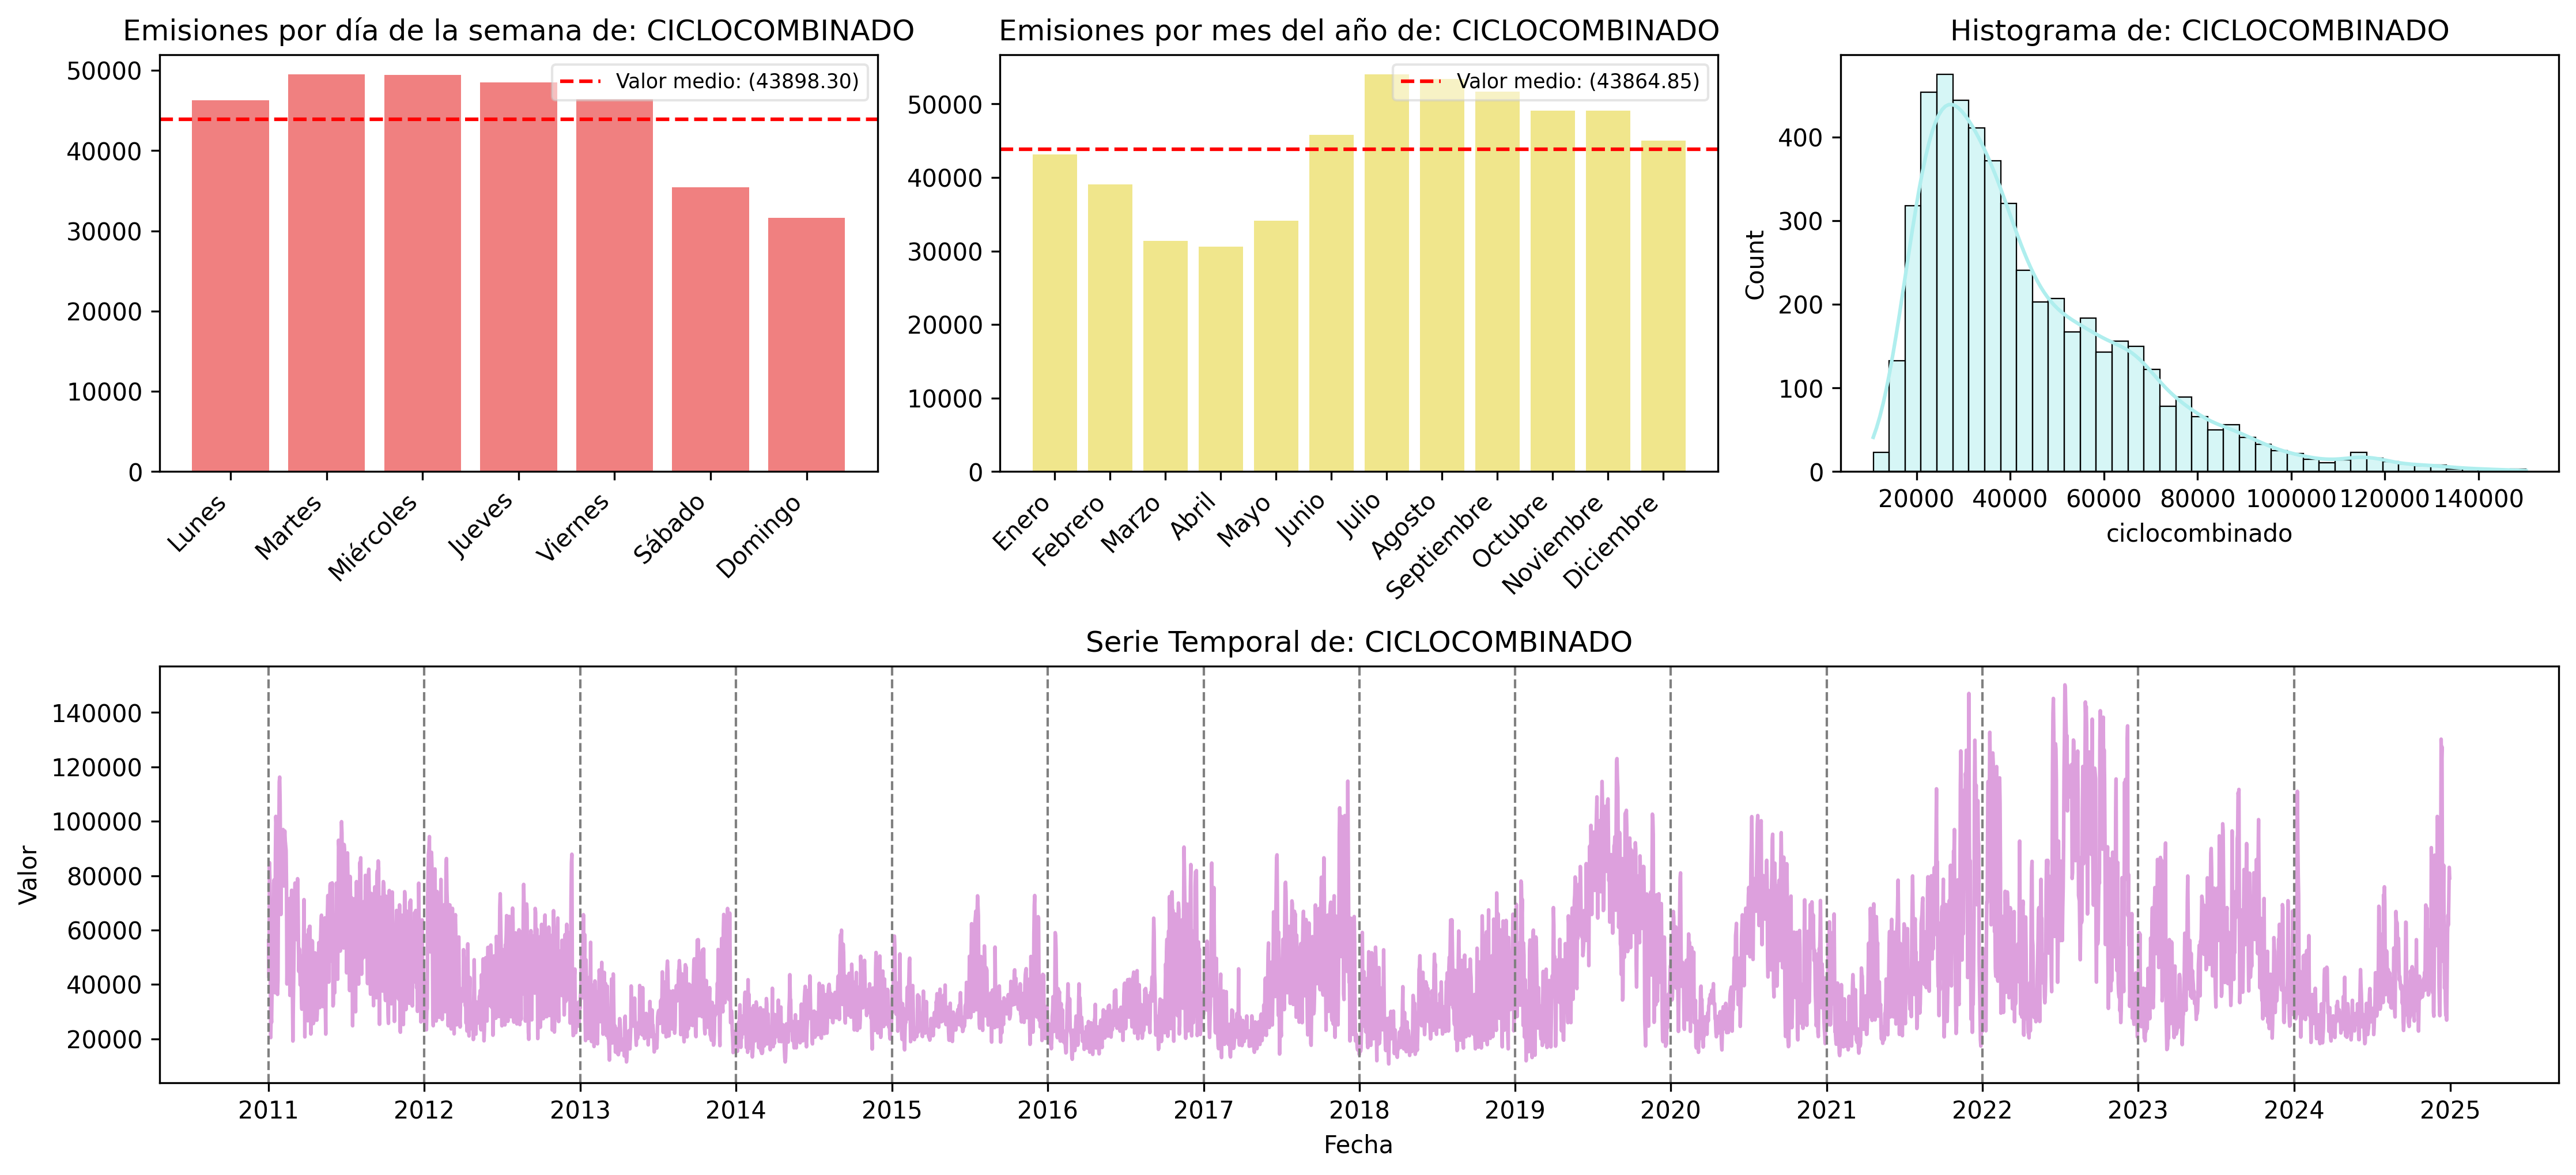

In [17]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','ciclocombinado')

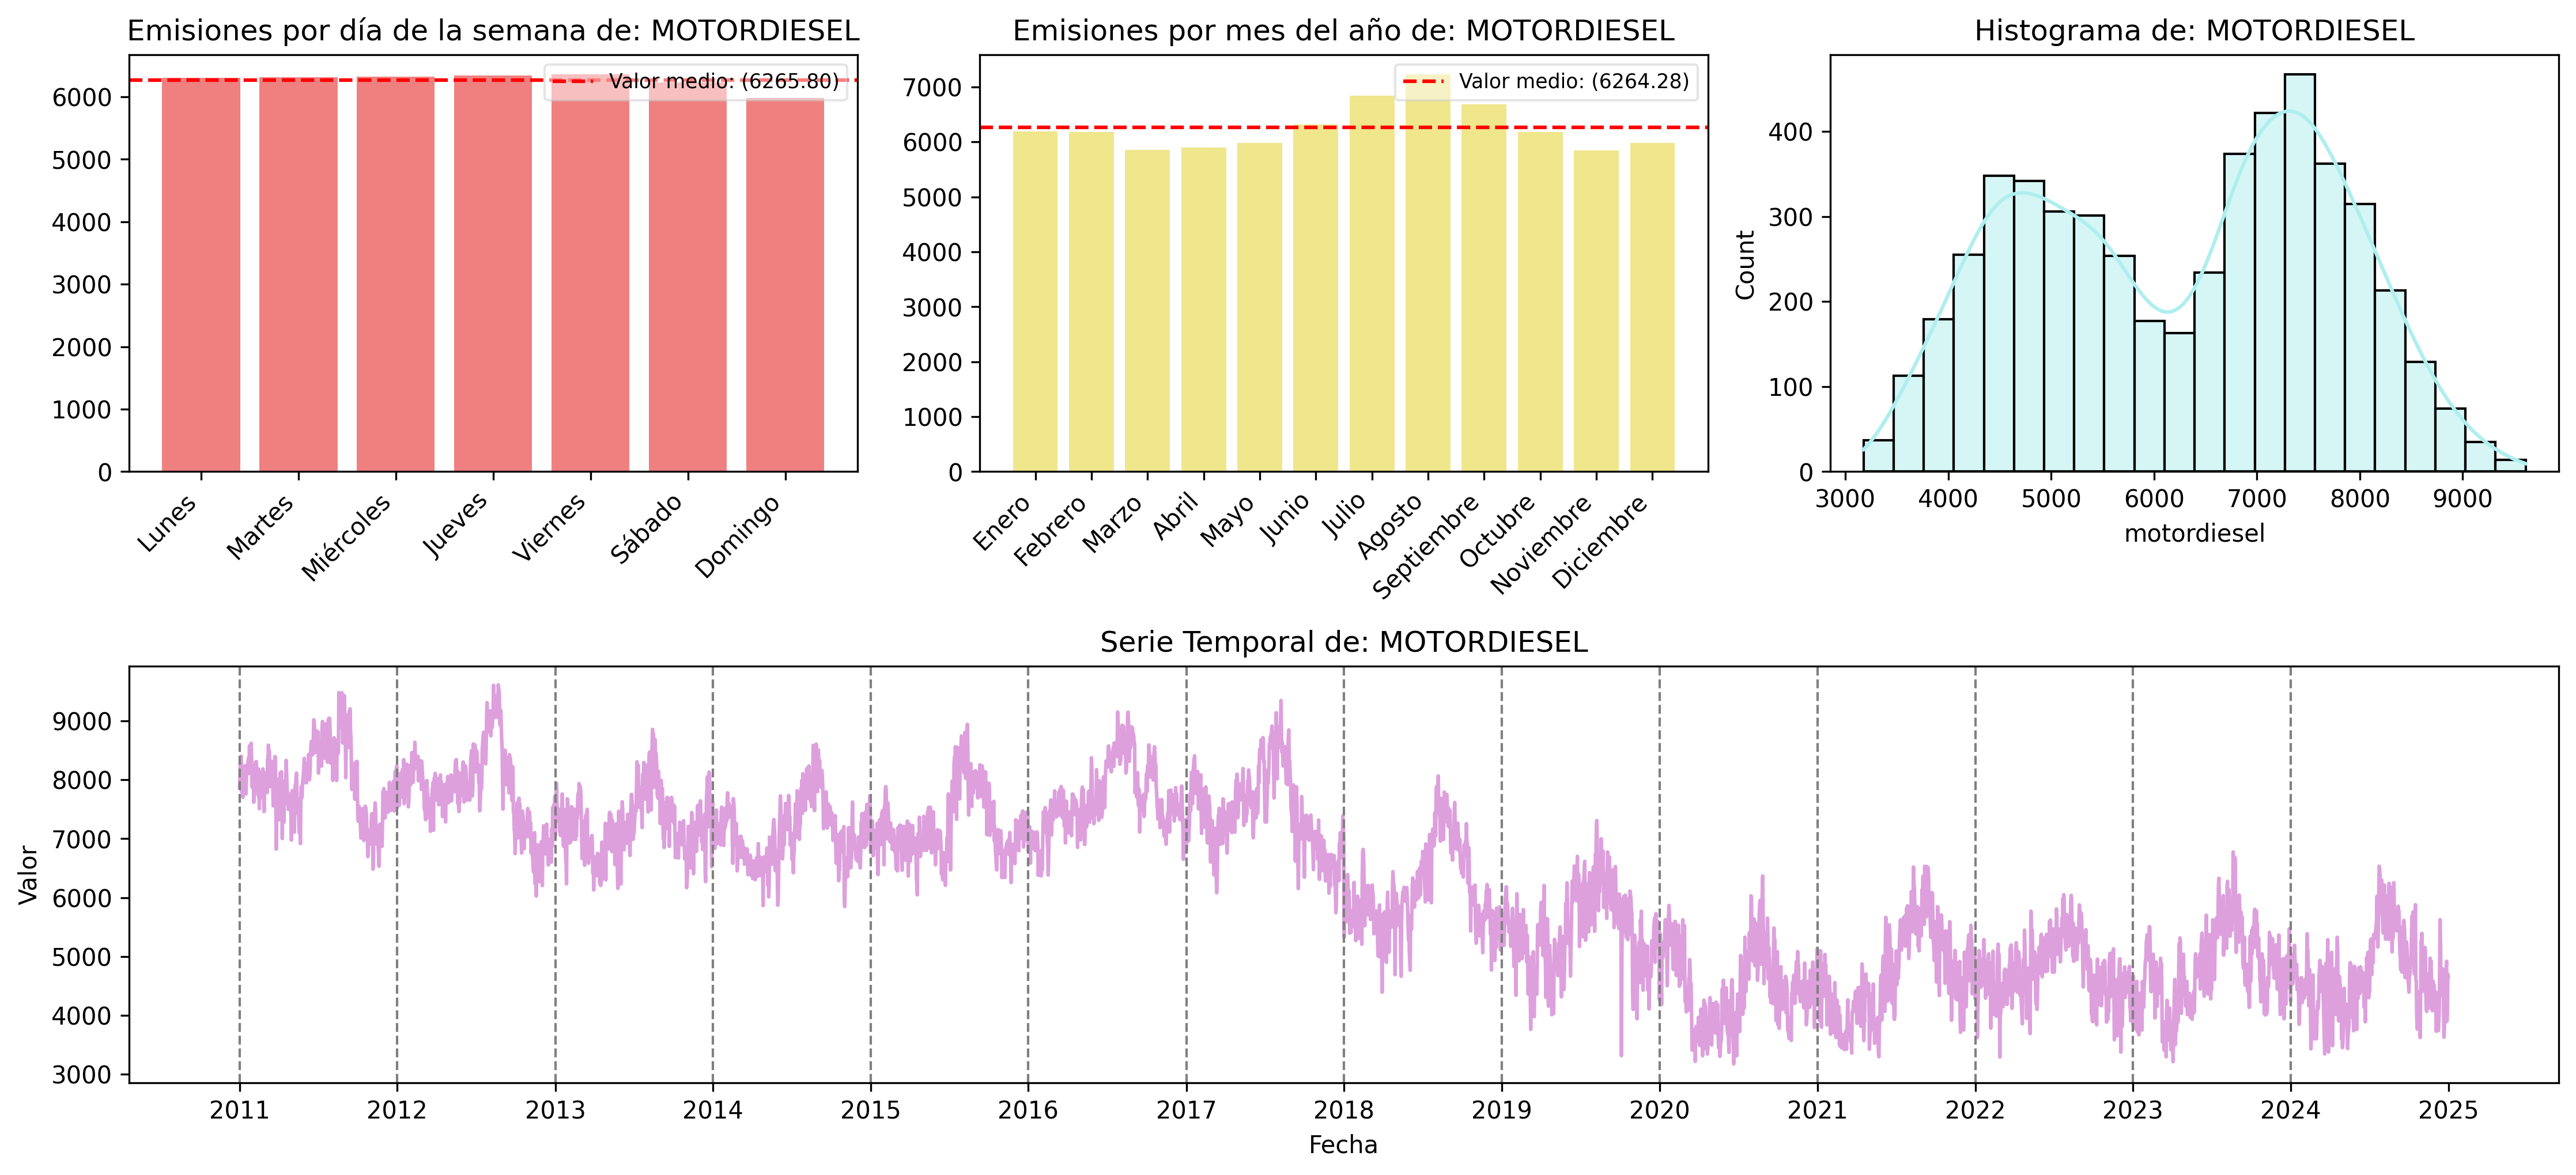

In [18]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','motordiesel')

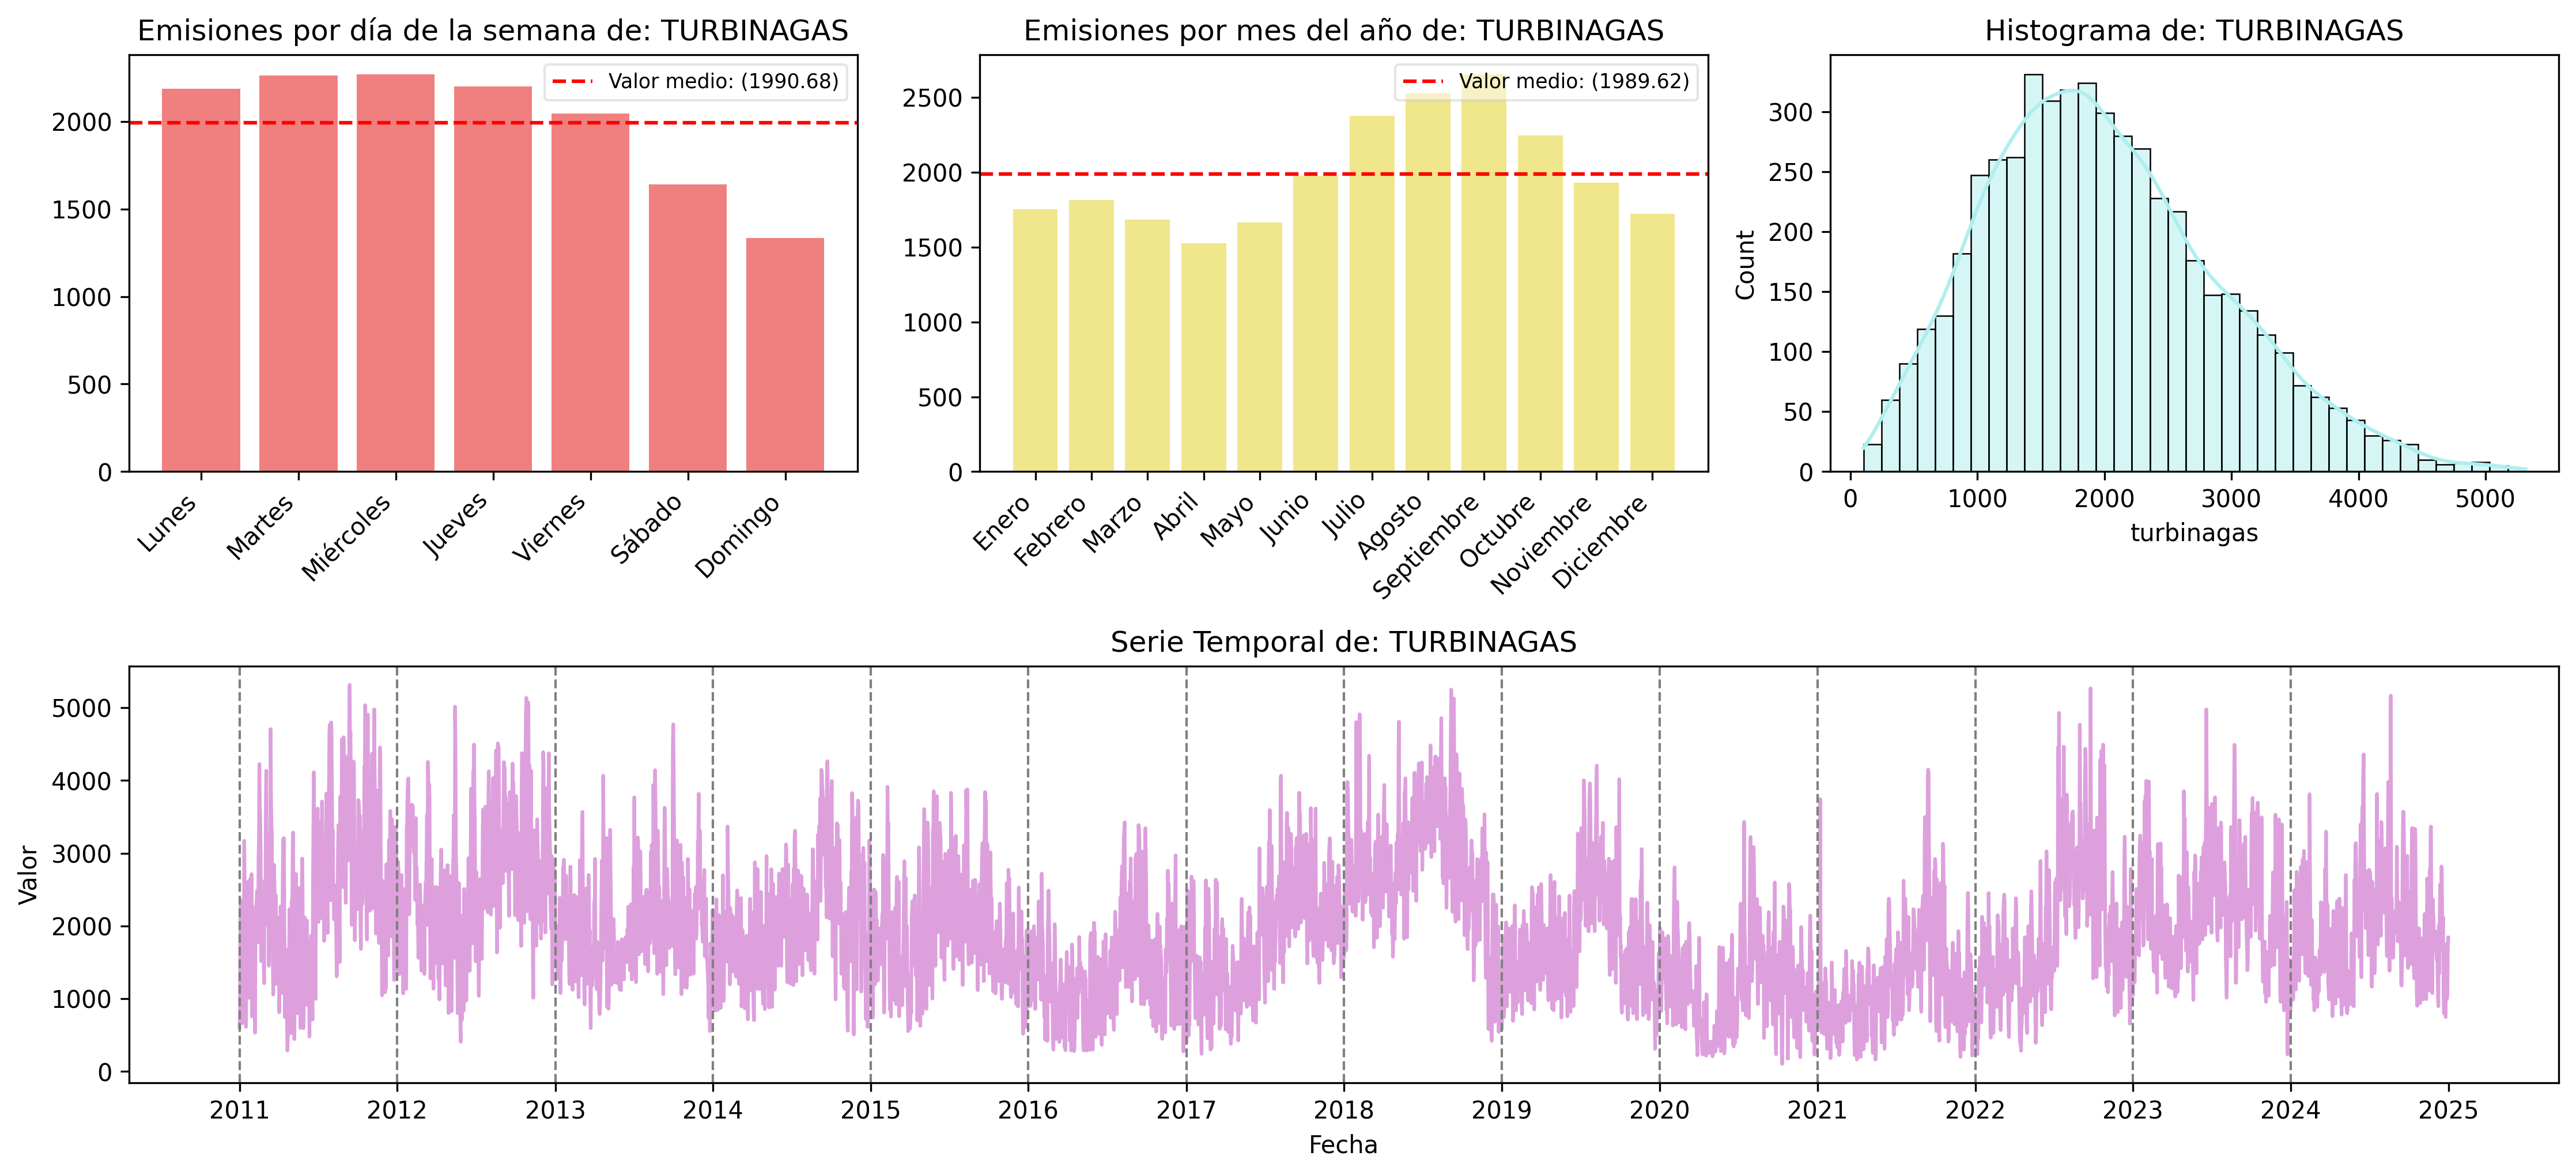

In [19]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','turbinagas')

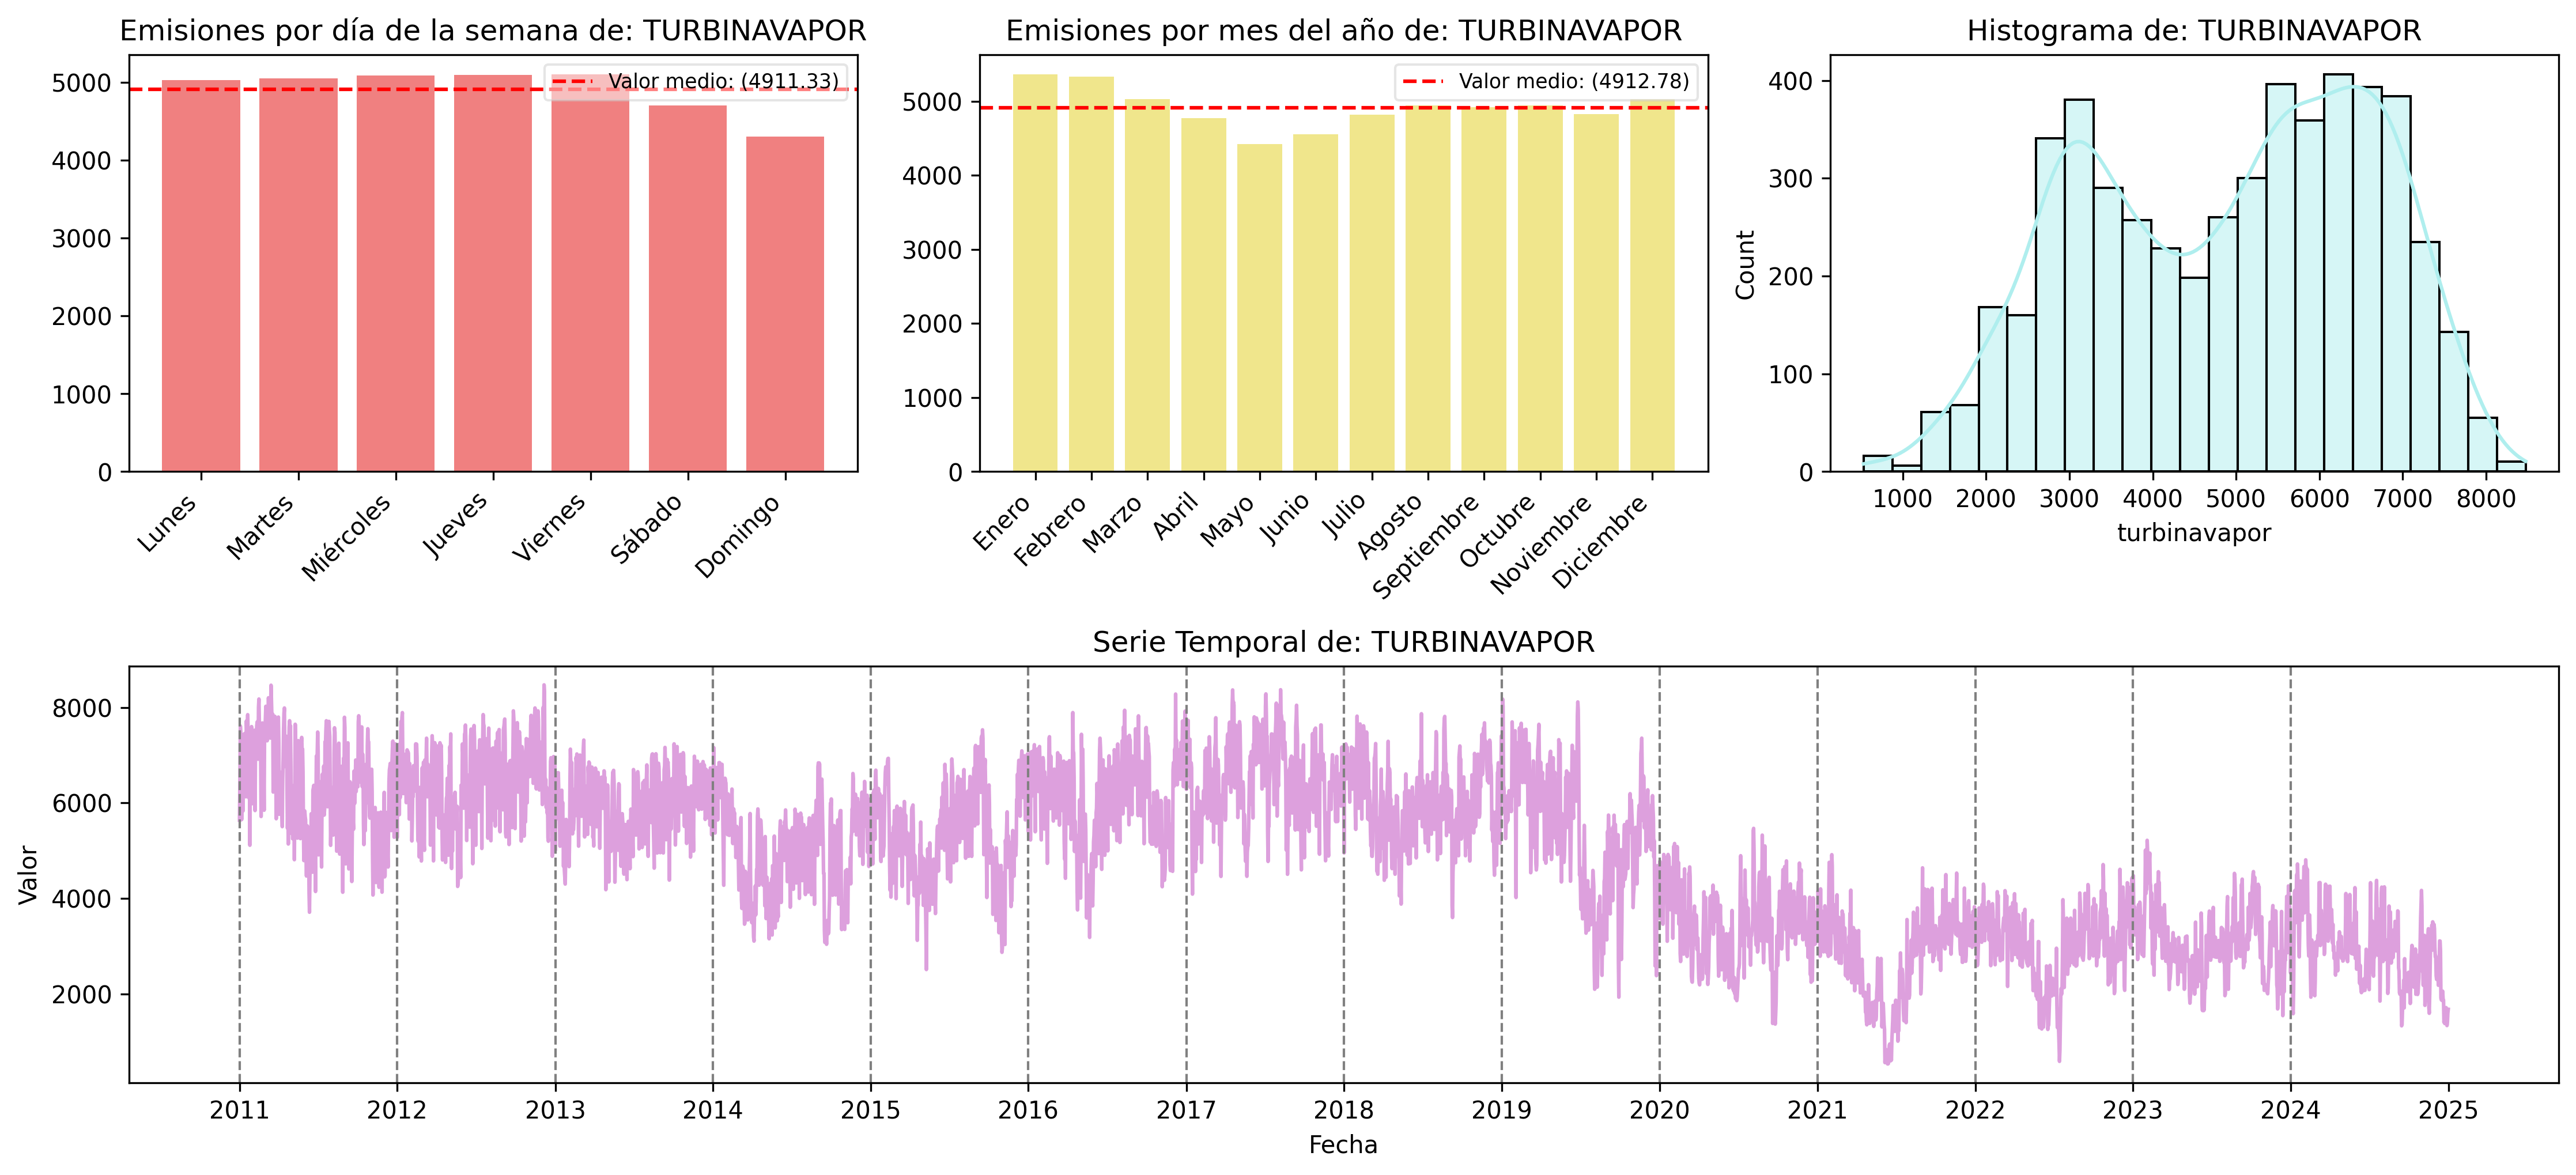

In [20]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','turbinavapor')

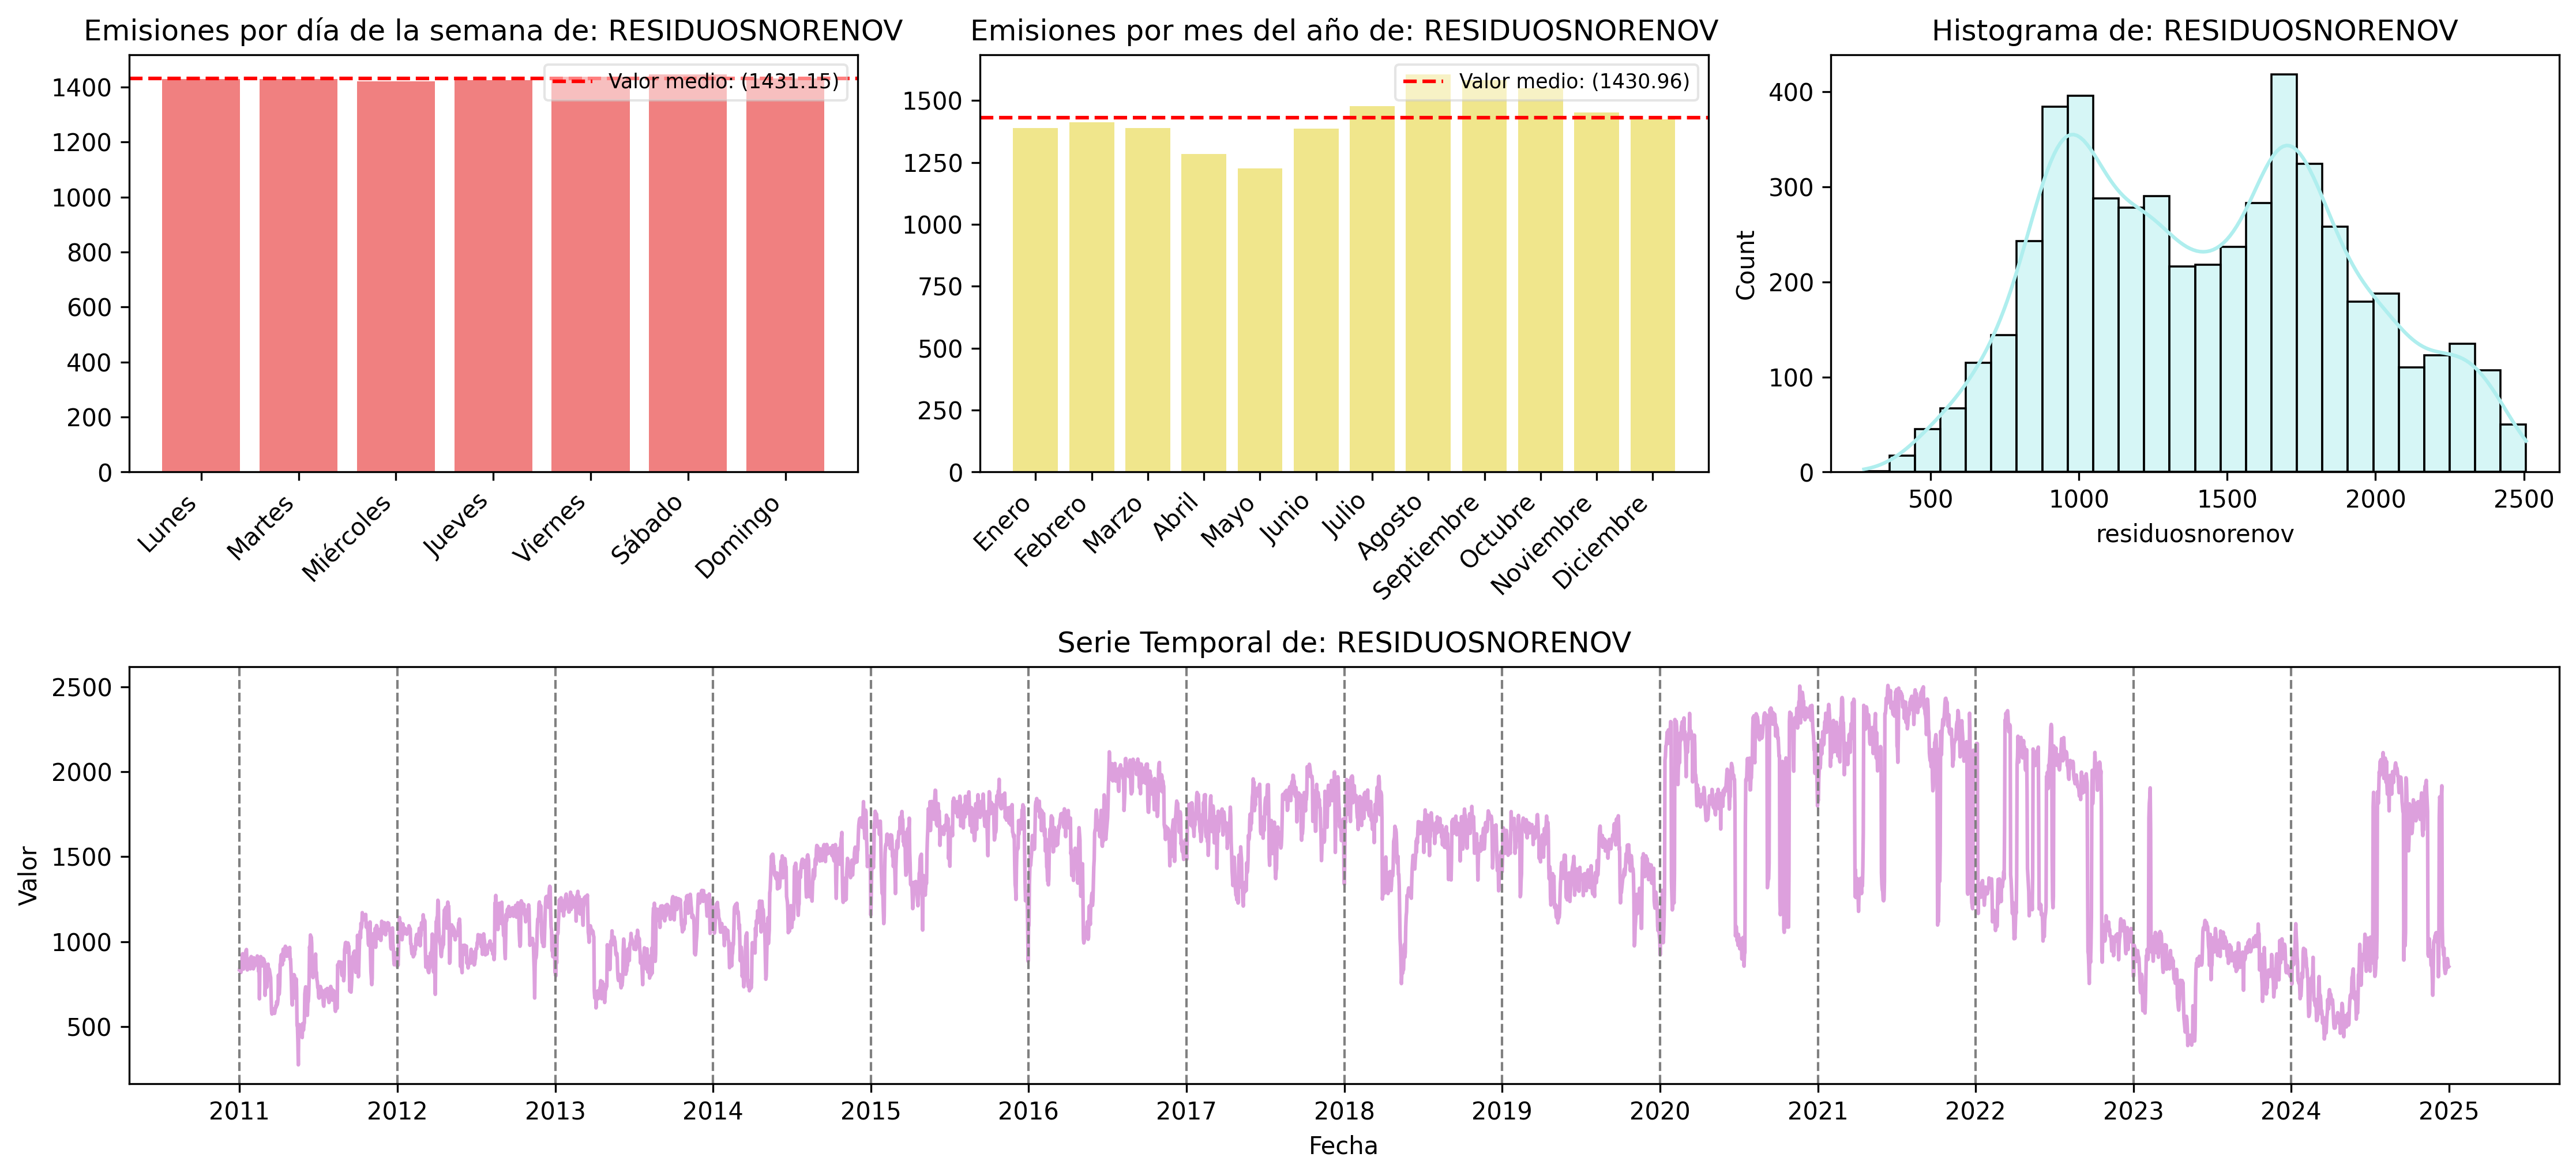

In [21]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','residuosnorenov')

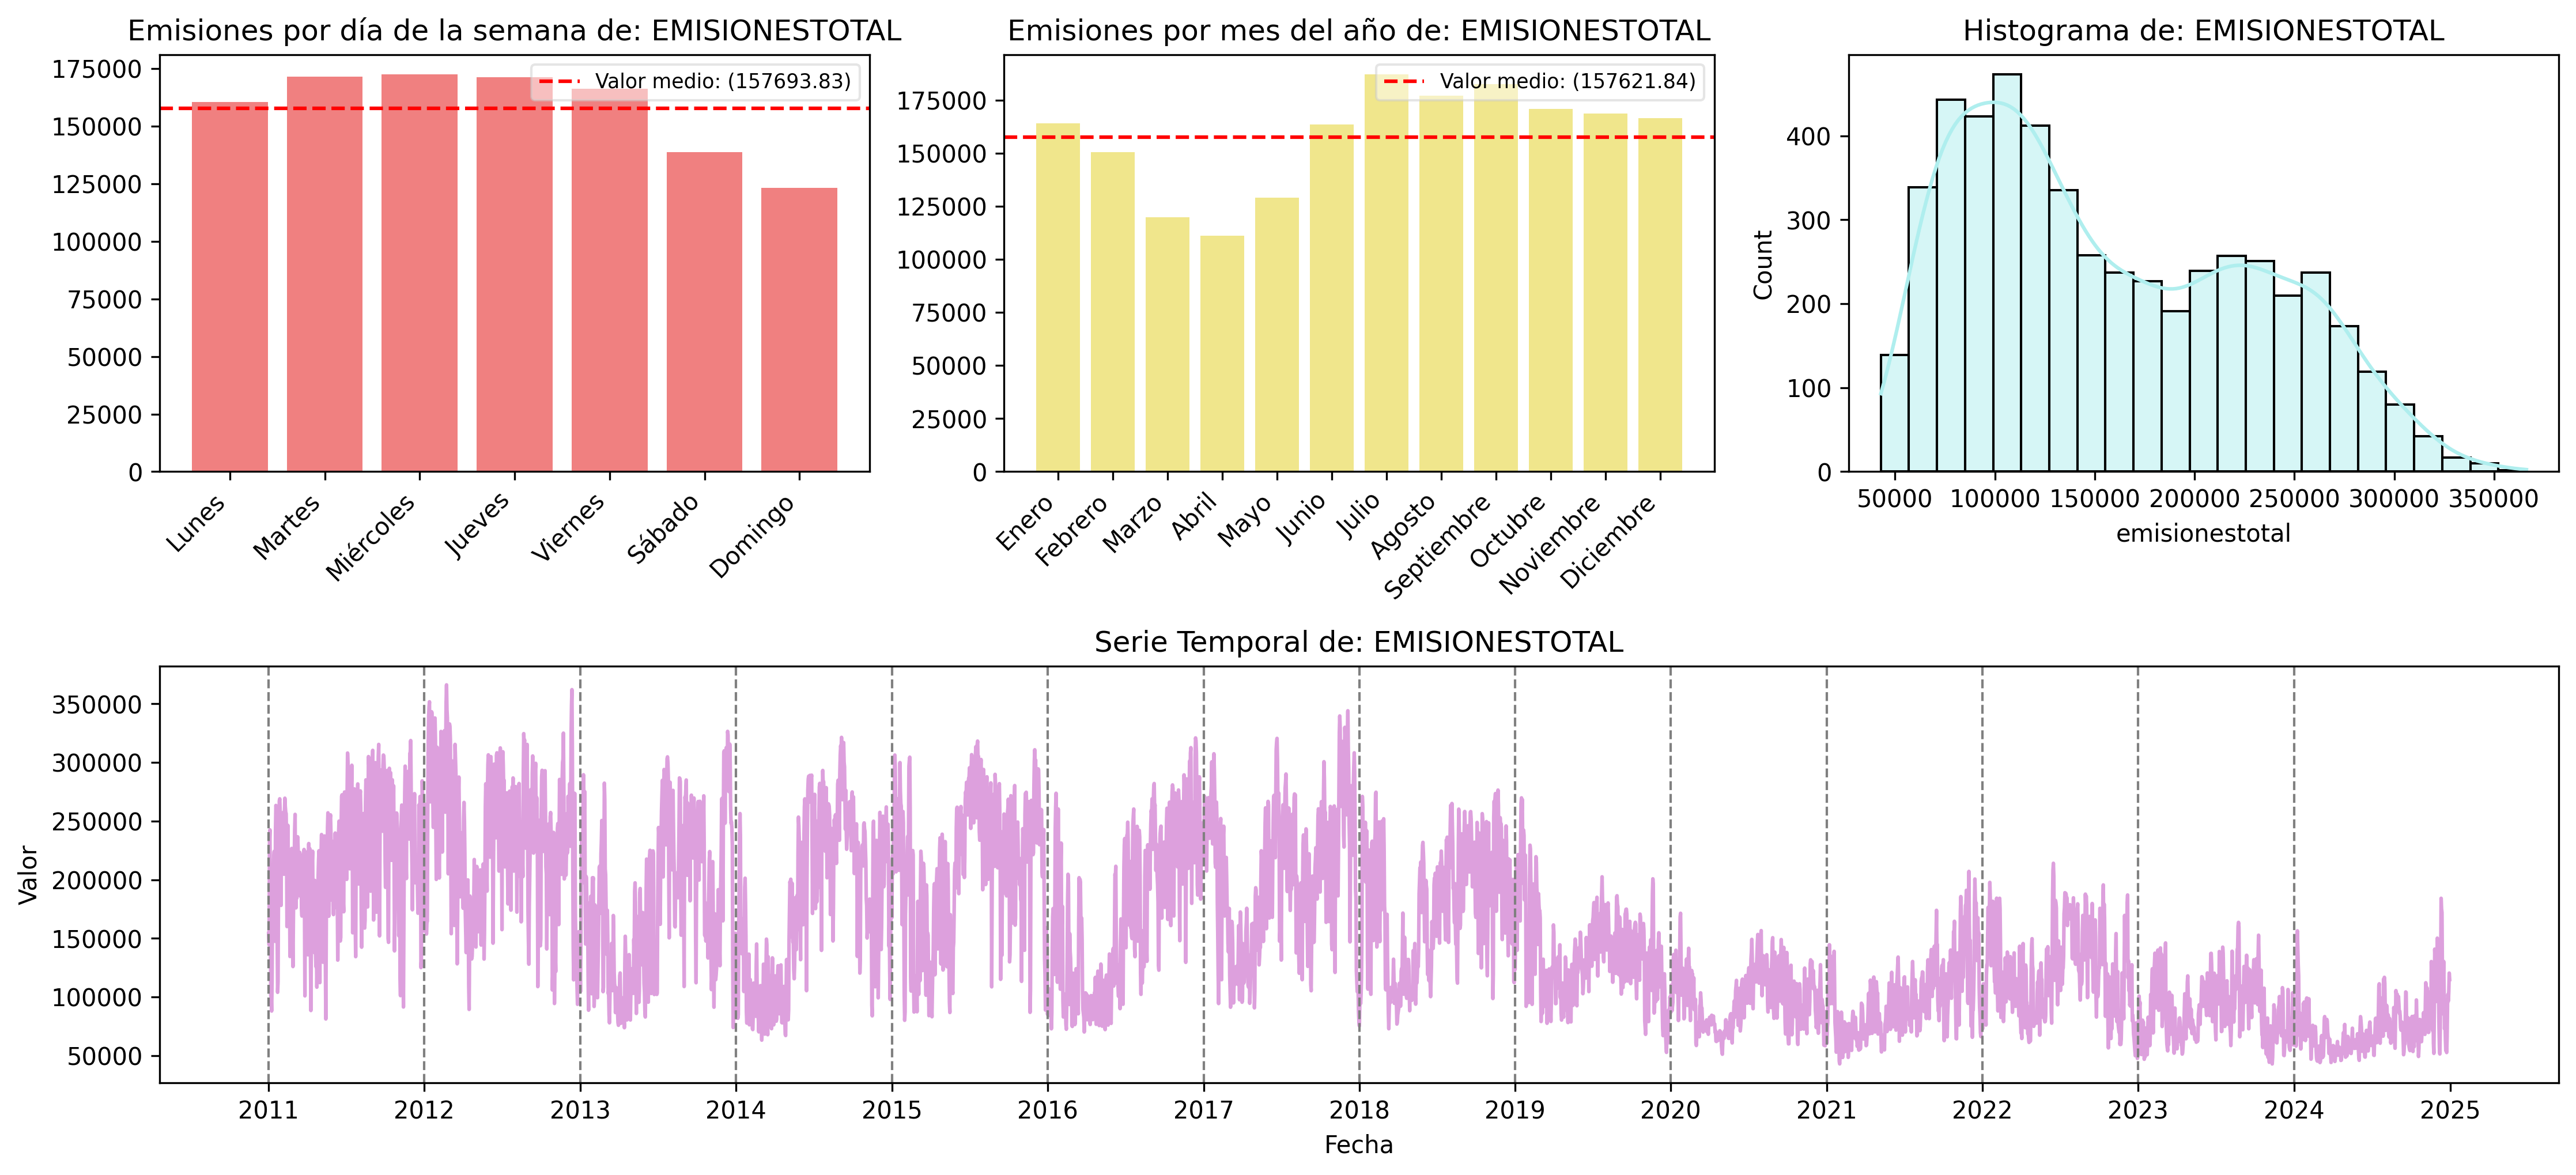

In [22]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','emisionestotal')

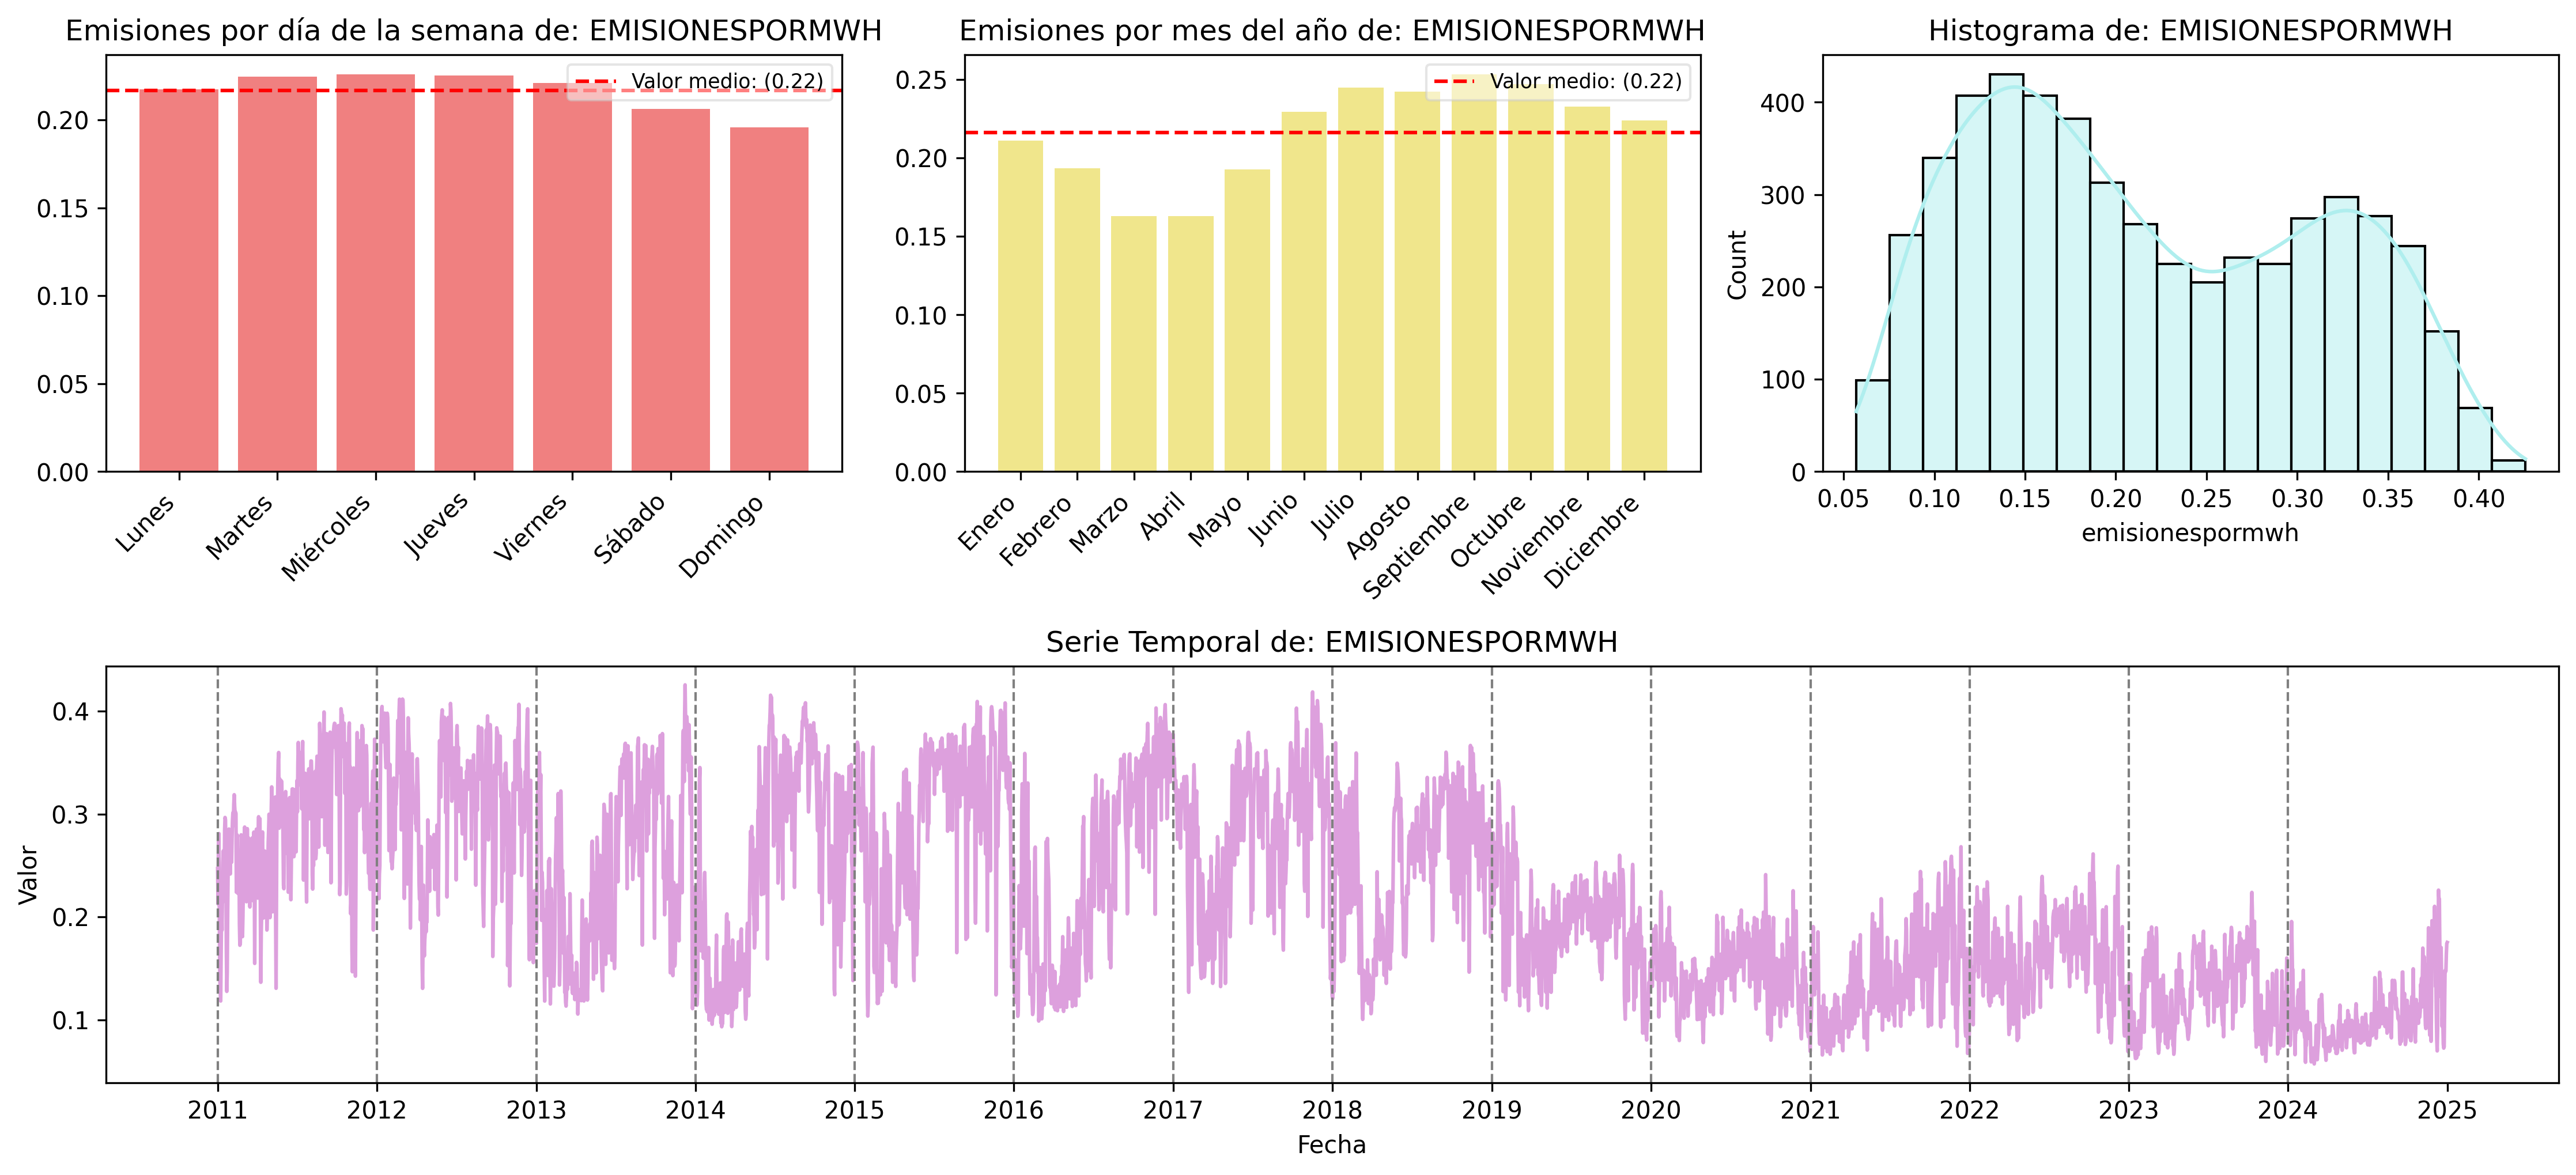

In [23]:
generarGraficasDistribucion_2filas_gen(dataframeemisiones,'fecha','Mes','DiaSemana','emisionespormwh')

Con esto damos por finalizada la parte del análisis de los datos de emisiones

In [22]:
# Insertar en BD
emisiones_InsertBD_SQLALCHEMY(dataframeemisiones)

NameError: name 'create_engine' is not defined